# ActorAttack — Probe Analysis

Trains linear probes on hidden states extracted from ActorAttack conversations.

**Sections:**
1. Load data (harmful + benign)
2. PCA overview
3. Conversation trajectories
4. Harmful vs benign probes per turn
5. Probe accuracy and AUC curves
6. Score distributions by class
7. Scores conditioned on verdict
8. Mean probe score trajectory
9. **Outcome probe (within harmful): predict jailbroken vs refusal from early turns**

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display

repo_root = Path("..").resolve()

# ── Config ────────────────────────────────────────────────────────────────────
FRAMEWORK = "actorattack"

FOLDERS = [
    "actorattack_harmful_v2",
    "actorattack_benign_v3",
]

REPR_ROOT = repo_root / "data" / "representations"

TRAIN_MAX_PAIR_ID = 79   # pairs 0–79 → train
TEST_MIN_PAIR_ID  = 80   # pairs 80–99 → test
MIN_EXAMPLES      = 50   # minimum per class to train a probe at turn k

FIG_DIR = repo_root / "notebooks" / "figures" / FRAMEWORK
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Framework: {FRAMEWORK}")
print(f"Loading from: {FOLDERS}")
print(f"Figures → {FIG_DIR}")

## 1. Load data

In [47]:
states_list = []
meta_list   = []

for folder in FOLDERS:
    s_path = REPR_ROOT / folder / "hidden_states.npy"
    m_path = REPR_ROOT / folder / "metadata.parquet"
    if not s_path.exists():
        print(f"Missing: {s_path} — skipping")
        continue
    states_list.append(np.load(str(s_path)).astype(np.float32))
    meta_list.append(pd.read_parquet(m_path))
    print(f"Loaded {folder}: {states_list[-1].shape[0]} vectors")

states = np.concatenate(states_list, axis=0)
meta   = pd.concat(meta_list, ignore_index=True)

print(f"\nTotal vectors: {len(states)}")
print()
display(meta.groupby(["split", "verdict"])["turn_idx"].count().rename("n_vectors"))
print()
print("Vectors per turn position:")
display(meta.groupby(["split", "turn_idx"])["pair_id"].count().rename("n_vectors").unstack("split"))

Loaded crescendo_harmful_v3: 2101 vectors
Loaded crescendo_benign_10_turns: 5940 vectors

Total vectors: 8041



split    verdict   
benign   near_miss     4940
         refusal       1000
harmful  jailbroken    1458
         near_miss      394
         refusal        249
Name: n_vectors, dtype: int64


Vectors per turn position:


split,benign,harmful
turn_idx,,
1,594,53
2,594,103
3,594,152
4,594,195
5,594,229
6,594,237
7,594,239
8,594,273
9,594,304


## 2. PCA overview

Fit PCA on all vectors for this framework. Plot harmful vs benign in PC space.

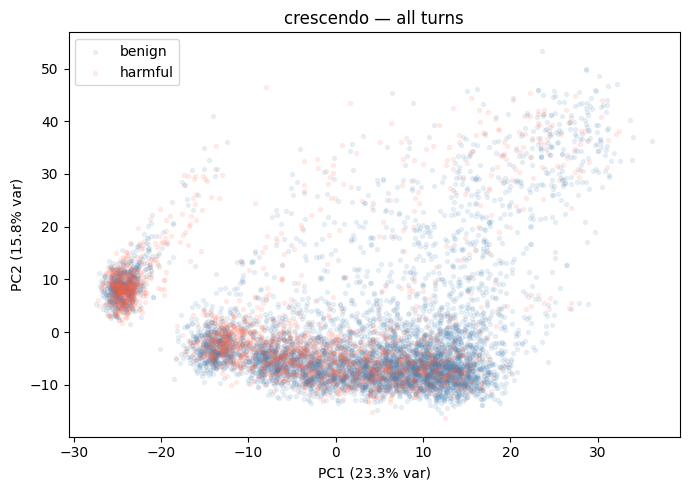

In [48]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(states)
meta["pc1"] = coords[:, 0]
meta["pc2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, "steelblue", "benign"), (1, "tomato", "harmful")]:
    m = meta["label"] == label
    ax.scatter(meta.loc[m, "pc1"], meta.loc[m, "pc2"],
               c=color, alpha=0.1, s=8, label=name, rasterized=True)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"{FRAMEWORK} — all turns")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_overview.png", dpi=150)
plt.show()

## 3. Conversation trajectories

Each conversation as a path through PCA space: turn 1 → turn 2 → … → turn N.
Sample a subset of conversations to avoid overplotting.

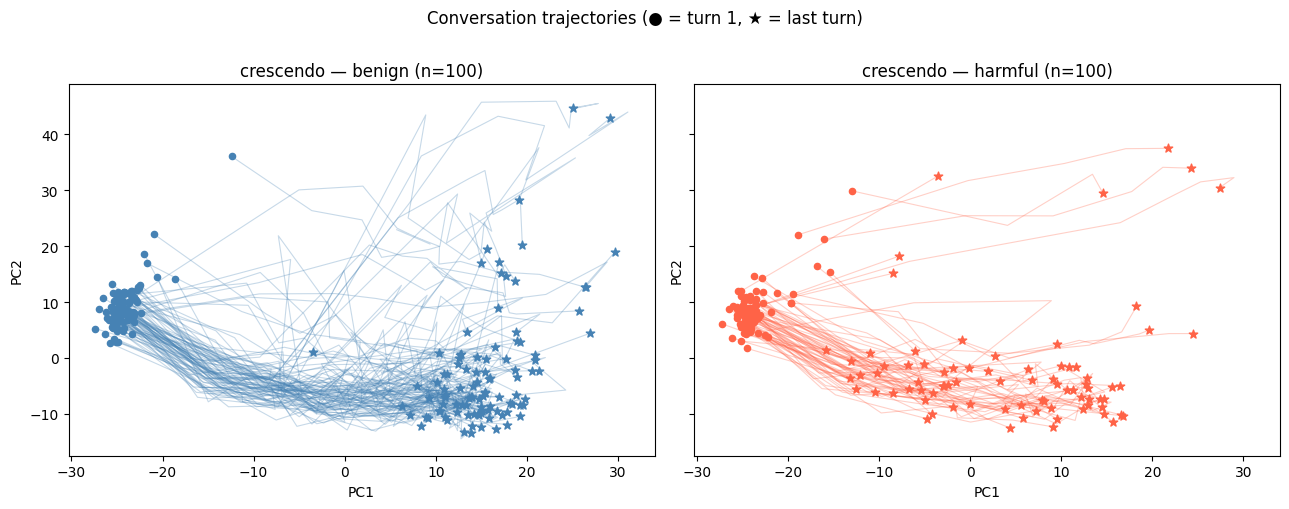

In [49]:
N_SAMPLE = 100   # conversations per class to plot

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, (split_name, label, color) in zip(axes, [("benign", 0, "steelblue"), ("harmful", 1, "tomato")]):
    split_meta = meta[meta["label"] == label]
    convs = split_meta[["pair_id", "attempt"]].drop_duplicates()
    sample = convs.sample(min(N_SAMPLE, len(convs)), random_state=42)

    for _, row in sample.iterrows():
        m = (split_meta["pair_id"] == row["pair_id"]) & (split_meta["attempt"] == row["attempt"])
        traj = split_meta[m].sort_values("turn_idx")
        if len(traj) < 2:
            continue
        ax.plot(traj["pc1"], traj["pc2"], color=color, alpha=0.3, linewidth=0.8)
        ax.scatter(traj["pc1"].iloc[0],  traj["pc2"].iloc[0],  color=color, s=20, zorder=3)
        ax.scatter(traj["pc1"].iloc[-1], traj["pc2"].iloc[-1], color=color, s=40, marker="*", zorder=4)

    ax.set_title(f"{FRAMEWORK} — {split_name} (n={N_SAMPLE})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Conversation trajectories (● = turn 1, ★ = last turn)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "trajectories.png", dpi=150)
plt.show()

## 4. Linear probes per turn position

Train one logistic regression per turn k on pair_ids 0–79, evaluate on 80–99.

In [50]:
turn_positions = sorted(meta["turn_idx"].unique())
probe_results = []

for k in turn_positions:
    m = meta["turn_idx"] == k
    X_k = states[m]
    y_k = meta.loc[m, "label"].values
    pid  = meta.loc[m, "pair_id"].values

    train = pid <= TRAIN_MAX_PAIR_ID
    test  = pid >= TEST_MIN_PAIR_ID

    X_tr, y_tr = X_k[train], y_k[train]
    X_te, y_te = X_k[test],  y_k[test]

    # Coverage check
    if (y_tr == 0).sum() < MIN_EXAMPLES or (y_tr == 1).sum() < MIN_EXAMPLES:
        print(f"Turn {k}: skipped (train coverage too low)")
        continue
    if (y_te == 0).sum() < 5 or (y_te == 1).sum() < 5:
        print(f"Turn {k}: skipped (test coverage too low)")
        continue

    # Scale features — essential for lbfgs convergence on 4096-dim hidden states
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # C=0.01: strong regularization needed for 4096-dim features with ~1600 samples
    clf = LogisticRegression(max_iter=5000, C=0.01, random_state=42)
    clf.fit(X_tr_s, y_tr)

    probs = clf.predict_proba(X_te_s)[:, 1]
    acc   = accuracy_score(y_te, clf.predict(X_te_s))
    auc   = roc_auc_score(y_te, probs)

    probe_results.append({"turn_idx": k, "accuracy": acc, "auc": auc,
                          "n_train": len(y_tr), "n_test": len(y_te),
                          "clf": clf, "scaler": scaler})
    print(f"Turn {k}: acc={acc:.3f}  AUC={auc:.3f}  (train={len(y_tr)}, test={len(y_te)})")

df_probes = pd.DataFrame([{k: v for k, v in r.items() if k not in ("clf", "scaler")} for r in probe_results])
print()
display(df_probes)

Turn 1: skipped (train coverage too low)
Turn 2: acc=0.942  AUC=0.972  (train=524, test=173)
Turn 3: acc=0.951  AUC=0.980  (train=563, test=183)
Turn 4: acc=0.942  AUC=0.988  (train=581, test=208)
Turn 5: acc=0.953  AUC=0.984  (train=612, test=211)
Turn 6: acc=0.935  AUC=0.969  (train=617, test=214)
Turn 7: acc=0.943  AUC=0.988  (train=606, test=227)
Turn 8: acc=0.942  AUC=0.984  (train=644, test=223)
Turn 9: acc=0.932  AUC=0.993  (train=662, test=236)
Turn 10: acc=0.928  AUC=0.975  (train=673, test=237)



,turn_idx,accuracy,auc,n_train,n_test
0,2,0.942197,0.971979,524,173
1,3,0.950820,0.980444,563,183
2,4,0.942308,0.987847,581,208
3,5,0.952607,0.984412,612,211
4,6,0.934579,0.968609,617,214
5,7,0.942731,0.987718,606,227
6,8,0.941704,0.983519,644,223
7,9,0.932203,0.993088,662,236
8,10,0.928270,0.974665,673,237


## 5. Probe accuracy and AUC across turns

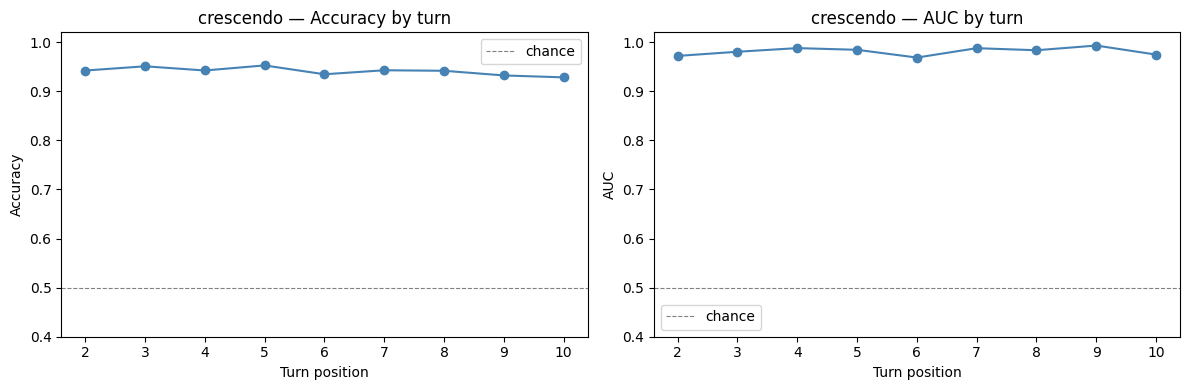

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ["accuracy", "auc"], ["Accuracy", "AUC"]):
    ax.plot(df_probes["turn_idx"], df_probes[metric], marker="o", color="steelblue")
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, label="chance")
    ax.set_xlabel("Turn position")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{FRAMEWORK} — {ylabel} by turn")
    ax.set_ylim(0.4, 1.02)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "probe_curves.png", dpi=150)
plt.show()

## 6. Probe score distributions by class

For each turn, plot the distribution of harmful probability scores for harmful vs benign conversations.

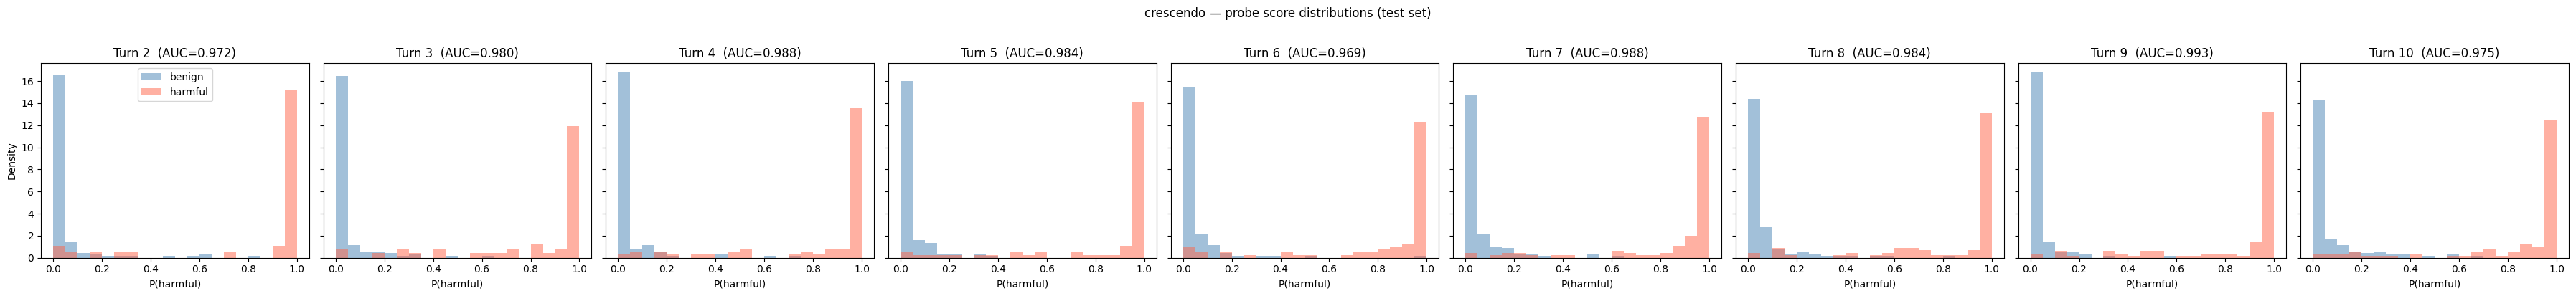

In [52]:
n_probes = len(probe_results)
fig, axes = plt.subplots(1, n_probes, figsize=(4 * n_probes, 4), sharey=True)
if n_probes == 1:
    axes = [axes]

for ax, result in zip(axes, probe_results):
    k      = result["turn_idx"]
    clf    = result["clf"]
    scaler = result["scaler"]
    m = (meta["turn_idx"] == k) & (meta["pair_id"] >= TEST_MIN_PAIR_ID)

    X_te  = scaler.transform(states[m])
    y_te  = meta.loc[m, "label"].values
    probs = clf.predict_proba(X_te)[:, 1]

    for label, color, name in [(0, "steelblue", "benign"), (1, "tomato", "harmful")]:
        ax.hist(probs[y_te == label], bins=20, range=(0, 1),
                color=color, alpha=0.5, label=name, density=True)

    ax.set_title(f"Turn {k}  (AUC={result['auc']:.3f})")
    ax.set_xlabel("P(harmful)")
    if ax == axes[0]:
        ax.set_ylabel("Density")
        ax.legend()

plt.suptitle(f"{FRAMEWORK} — probe score distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Probe scores conditioned on verdict

Break down P(harmful) distributions by verdict (jailbroken / near_miss / refusal) to see
whether the signal at turn 6 comes from jailbroken conversations only.

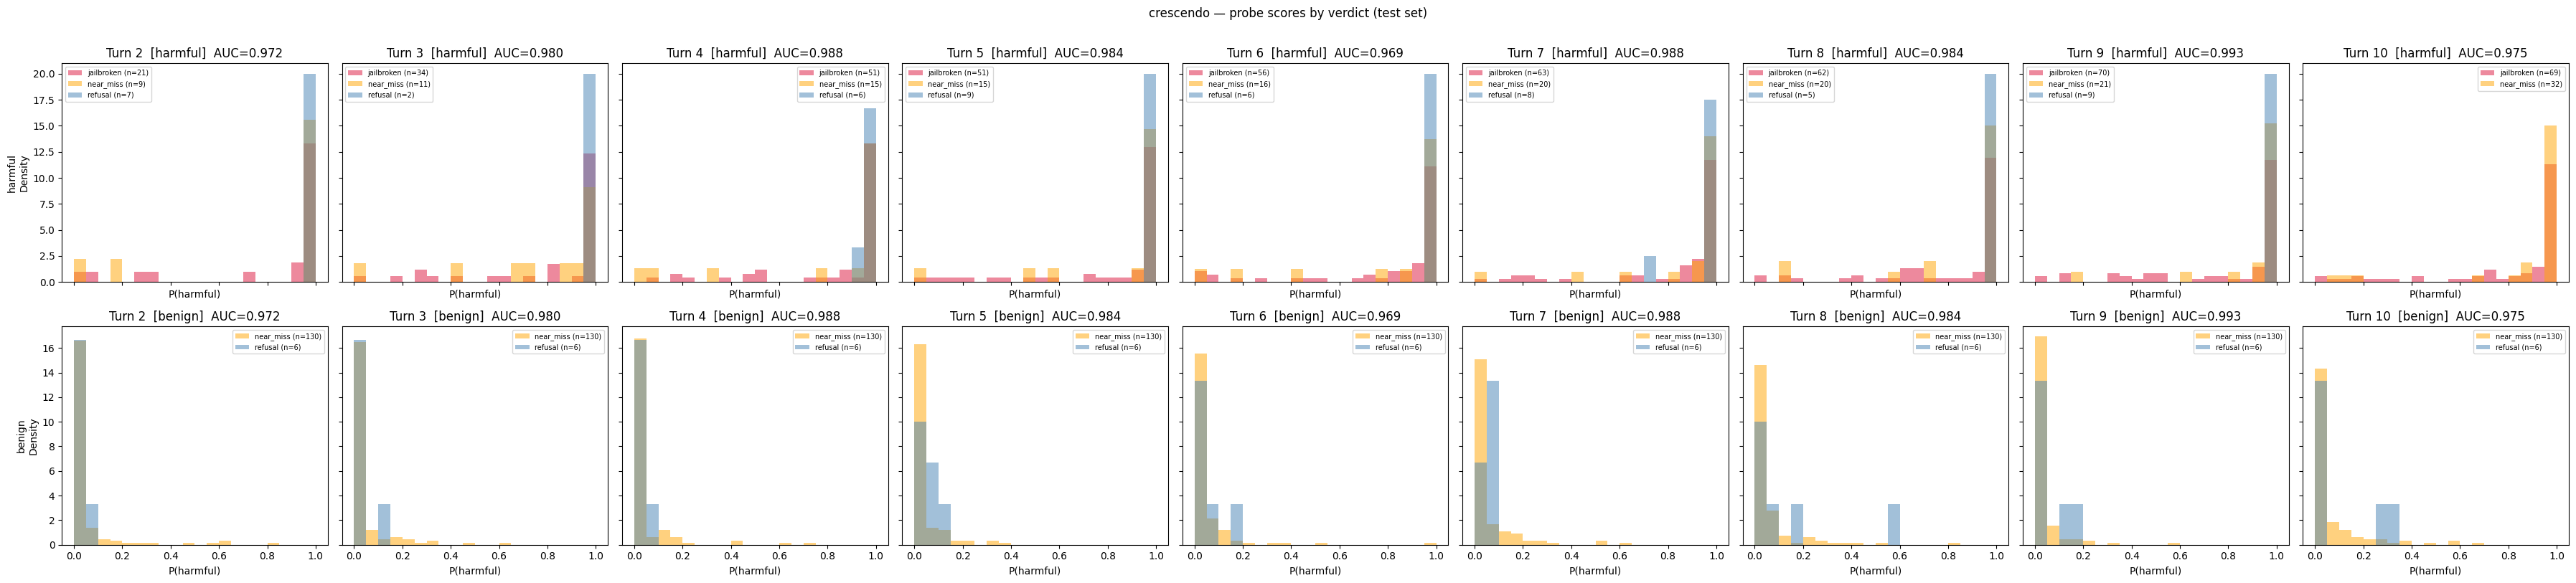

In [53]:
verdicts   = ["jailbroken", "near_miss", "refusal"]
verdict_colors = {"jailbroken": "crimson", "near_miss": "orange", "refusal": "steelblue"}
splits     = [("harmful", 1), ("benign", 0)]

n_probes = len(probe_results)
fig, axes = plt.subplots(len(splits), n_probes,
                         figsize=(4 * n_probes, 4 * len(splits)),
                         sharey="row", sharex=True)
if n_probes == 1:
    axes = axes.reshape(-1, 1)

for row_idx, (split_name, label) in enumerate(splits):
    for col_idx, result in enumerate(probe_results):
        ax     = axes[row_idx, col_idx]
        k      = result["turn_idx"]
        clf    = result["clf"]
        scaler = result["scaler"]

        m = (meta["turn_idx"] == k) & (meta["pair_id"] >= TEST_MIN_PAIR_ID) & (meta["label"] == label)
        if m.sum() == 0:
            ax.set_visible(False)
            continue

        X_te  = scaler.transform(states[m])
        probs = clf.predict_proba(X_te)[:, 1]
        v_te  = meta.loc[m, "verdict"].values

        for verdict in verdicts:
            mask = v_te == verdict
            if mask.sum() == 0:
                continue
            ax.hist(probs[mask], bins=20, range=(0, 1),
                    color=verdict_colors[verdict], alpha=0.5,
                    label=f"{verdict} (n={mask.sum()})", density=True)

        ax.set_title(f"Turn {k}  [{split_name}]  AUC={result['auc']:.3f}")
        ax.set_xlabel("P(harmful)")
        if col_idx == 0:
            ax.set_ylabel(f"{split_name}\nDensity")
        ax.legend(fontsize=7)

plt.suptitle(f"{FRAMEWORK} — probe scores by verdict (test set)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "score_by_verdict.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Mean probe score trajectory

Average P(harmful) across turns, separately for harmful and benign conversations.

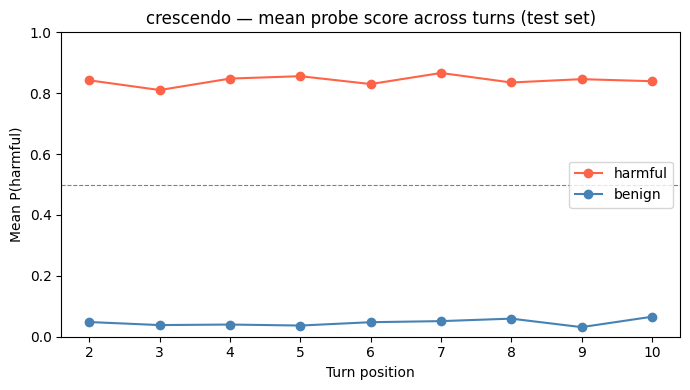

In [54]:
rows = []
for result in probe_results:
    k      = result["turn_idx"]
    clf    = result["clf"]
    scaler = result["scaler"]
    m = (meta["turn_idx"] == k) & (meta["pair_id"] >= TEST_MIN_PAIR_ID)

    X_te  = scaler.transform(states[m])
    probs = clf.predict_proba(X_te)[:, 1]
    y     = meta.loc[m, "label"].values

    rows.append({"turn_idx": k, "split": "harmful", "mean_score": probs[y == 1].mean()})
    rows.append({"turn_idx": k, "split": "benign",  "mean_score": probs[y == 0].mean()})

df_traj = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for split, color in [("harmful", "tomato"), ("benign", "steelblue")]:
    d = df_traj[df_traj["split"] == split]
    ax.plot(d["turn_idx"], d["mean_score"], marker="o", color=color, label=split)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8)
ax.set_xlabel("Turn position")
ax.set_ylabel("Mean P(harmful)")
ax.set_title(f"{FRAMEWORK} — mean probe score across turns (test set)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_probe_trajectory.png", dpi=150)
plt.show()

## 9. Outcome probe: predict jailbroken vs refusal from early turns

The ablation (notebook 06) shows that multi-turn warm-up turns significantly boost ASR
(32.7% multi-turn vs 7.6% single-turn condensed). This means the warm-up turns are doing
real work — but the harmful vs benign probe above can't detect this because it compares
across the dataset split, not within it.

This section probes *within* harmful conversations only:
- **Label:** jailbroken = 1, refusal = 0 (near_miss excluded — ambiguous outcome)
- **Question:** at turn k (before the final harmful request), can the hidden state predict
  whether this conversation will succeed?
- **Expectation:** if ActorAttack's fictional framing is gradually building compliance,
  AUC should rise across turns 1–5 even before the explicit harmful request at turn 6.

In [ ]:
# ── Filter to harmful only, drop near_miss ────────────────────────────────────
meta_h = meta[
    (meta["label"] == 1) &
    (meta["verdict"].isin(["jailbroken", "refusal"]))
].copy()
meta_h["outcome"] = (meta_h["verdict"] == "jailbroken").astype(int)

print(f"Harmful vectors (jailbroken + refusal): {len(meta_h)}")
print(meta_h.groupby(["verdict", "turn_idx"])["pair_id"].count().rename("n").unstack("turn_idx"))

# ── Outcome probe at each turn ────────────────────────────────────────────────
turn_positions = sorted(meta_h["turn_idx"].unique())
outcome_results = []

for k in turn_positions:
    m = meta_h["turn_idx"] == k
    idx = meta_h.index[m]

    X_k  = states[idx]
    y_k  = meta_h.loc[idx, "outcome"].values
    pid  = meta_h.loc[idx, "pair_id"].values

    train = pid <= TRAIN_MAX_PAIR_ID
    test  = pid >= TEST_MIN_PAIR_ID

    X_tr, y_tr = X_k[train], y_k[train]
    X_te, y_te = X_k[test],  y_k[test]

    # Coverage check
    if (y_tr == 0).sum() < MIN_EXAMPLES or (y_tr == 1).sum() < MIN_EXAMPLES:
        print(f"Turn {k}: skipped (train — jailbroken={( y_tr==1).sum()}, refusal={(y_tr==0).sum()})")
        continue
    if (y_te == 0).sum() < 5 or (y_te == 1).sum() < 5:
        print(f"Turn {k}: skipped (test coverage too low)")
        continue

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = LogisticRegression(max_iter=5000, C=0.01, random_state=42)
    clf.fit(X_tr_s, y_tr)

    probs = clf.predict_proba(X_te_s)[:, 1]
    acc   = accuracy_score(y_te, clf.predict(X_te_s))
    auc   = roc_auc_score(y_te, probs)

    outcome_results.append({
        "turn_idx": k, "accuracy": acc, "auc": auc,
        "n_train": len(y_tr), "n_test": len(y_te),
        "n_train_jb": (y_tr == 1).sum(), "n_train_ref": (y_tr == 0).sum(),
        "clf": clf, "scaler": scaler,
    })
    print(f"Turn {k}: acc={acc:.3f}  AUC={auc:.3f}  "
          f"(train jb={( y_tr==1).sum()} ref={(y_tr==0).sum()}, test n={len(y_te)})")

df_outcome = pd.DataFrame([{k: v for k, v in r.items() if k not in ("clf", "scaler")}
                            for r in outcome_results])
print()
display(df_outcome)

In [ ]:
# ── AUC curve across turns ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: outcome AUC vs turn
ax = axes[0]
ax.plot(df_outcome["turn_idx"], df_outcome["auc"], marker="o", color="purple", label="jailbroken vs refusal")
ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, label="chance")
ax.set_xlabel("Turn position")
ax.set_ylabel("AUC")
ax.set_title(f"{FRAMEWORK} — outcome probe AUC\n(within harmful: jailbroken vs refusal)")
ax.set_ylim(0.4, 1.02)
ax.legend()

# Right: overlay outcome AUC vs harmful/benign AUC for comparison
ax = axes[1]
if len(df_probes):
    ax.plot(df_probes["turn_idx"], df_probes["auc"], marker="o", color="steelblue",
            label="harmful vs benign")
ax.plot(df_outcome["turn_idx"], df_outcome["auc"], marker="o", color="purple",
        label="jailbroken vs refusal (within harmful)")
ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, label="chance")
ax.set_xlabel("Turn position")
ax.set_ylabel("AUC")
ax.set_title(f"{FRAMEWORK} — probe AUC comparison")
ax.set_ylim(0.4, 1.02)
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "outcome_probe_auc.png", dpi=150)
plt.show()

# ── Mean P(jailbroken) trajectory ────────────────────────────────────────────
rows_oc = []
for result in outcome_results:
    k      = result["turn_idx"]
    clf    = result["clf"]
    scaler = result["scaler"]
    m   = (meta_h["turn_idx"] == k) & (meta_h["pair_id"] >= TEST_MIN_PAIR_ID)
    idx = meta_h.index[m]

    X_te  = scaler.transform(states[idx])
    probs = clf.predict_proba(X_te)[:, 1]
    y     = meta_h.loc[idx, "outcome"].values

    rows_oc.append({"turn_idx": k, "outcome": "jailbroken", "mean_score": probs[y == 1].mean()})
    rows_oc.append({"turn_idx": k, "outcome": "refusal",    "mean_score": probs[y == 0].mean()})

df_oc_traj = pd.DataFrame(rows_oc)

fig, ax = plt.subplots(figsize=(7, 4))
for outcome, color in [("jailbroken", "crimson"), ("refusal", "steelblue")]:
    d = df_oc_traj[df_oc_traj["outcome"] == outcome]
    ax.plot(d["turn_idx"], d["mean_score"], marker="o", color=color, label=outcome)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8)
ax.set_xlabel("Turn position")
ax.set_ylabel("Mean P(jailbroken)")
ax.set_title(f"{FRAMEWORK} — mean outcome probe score across turns\n(within harmful, test set)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "outcome_probe_trajectory.png", dpi=150)
plt.show()